In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ISLP import load_data

In [2]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


- crim: per capita crime rate by town.

- zn: proportion of residential land zoned for lots over 25,000 sq.ft.

- indus: proportion of non-retail business acres per town.

- chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

- nox: nitrogen oxides concentration (parts per 10 million).

- rm: average number of rooms per dwelling.

- age: proportion of owner-occupied units built prior to 1940.

- dis: weighted mean of distances to five Boston employment centres.

- rad: index of accessibility to radial highways.

- tax: full-value property-tax rate per $10,000.

- ptratio: pupil-teacher ratio by town.

- lstat: lower status of the population (percent).

- medv: median value of owner-occupied homes in $1000s.


In [4]:
boston_info = pd.DataFrame({
    'Non-null count': boston.count(),
    'Dtypes': boston.dtypes,
    'Uniques': boston.nunique()
}).reset_index(names='Columns')
display(boston_info)

,Columns,Non-null count,Dtypes,Uniques
0,crim,506,float64,504
1,zn,506,float64,26
2,indus,506,float64,76
3,chas,506,int64,2
4,nox,506,float64,81
5,rm,506,float64,446
6,age,506,float64,356
7,dis,506,float64,412
8,rad,506,int64,9
9,tax,506,int64,66


C:\Users\pc\AppData\Local\Temp\ipykernel_3228\1157741358.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(boston, ax=ax);


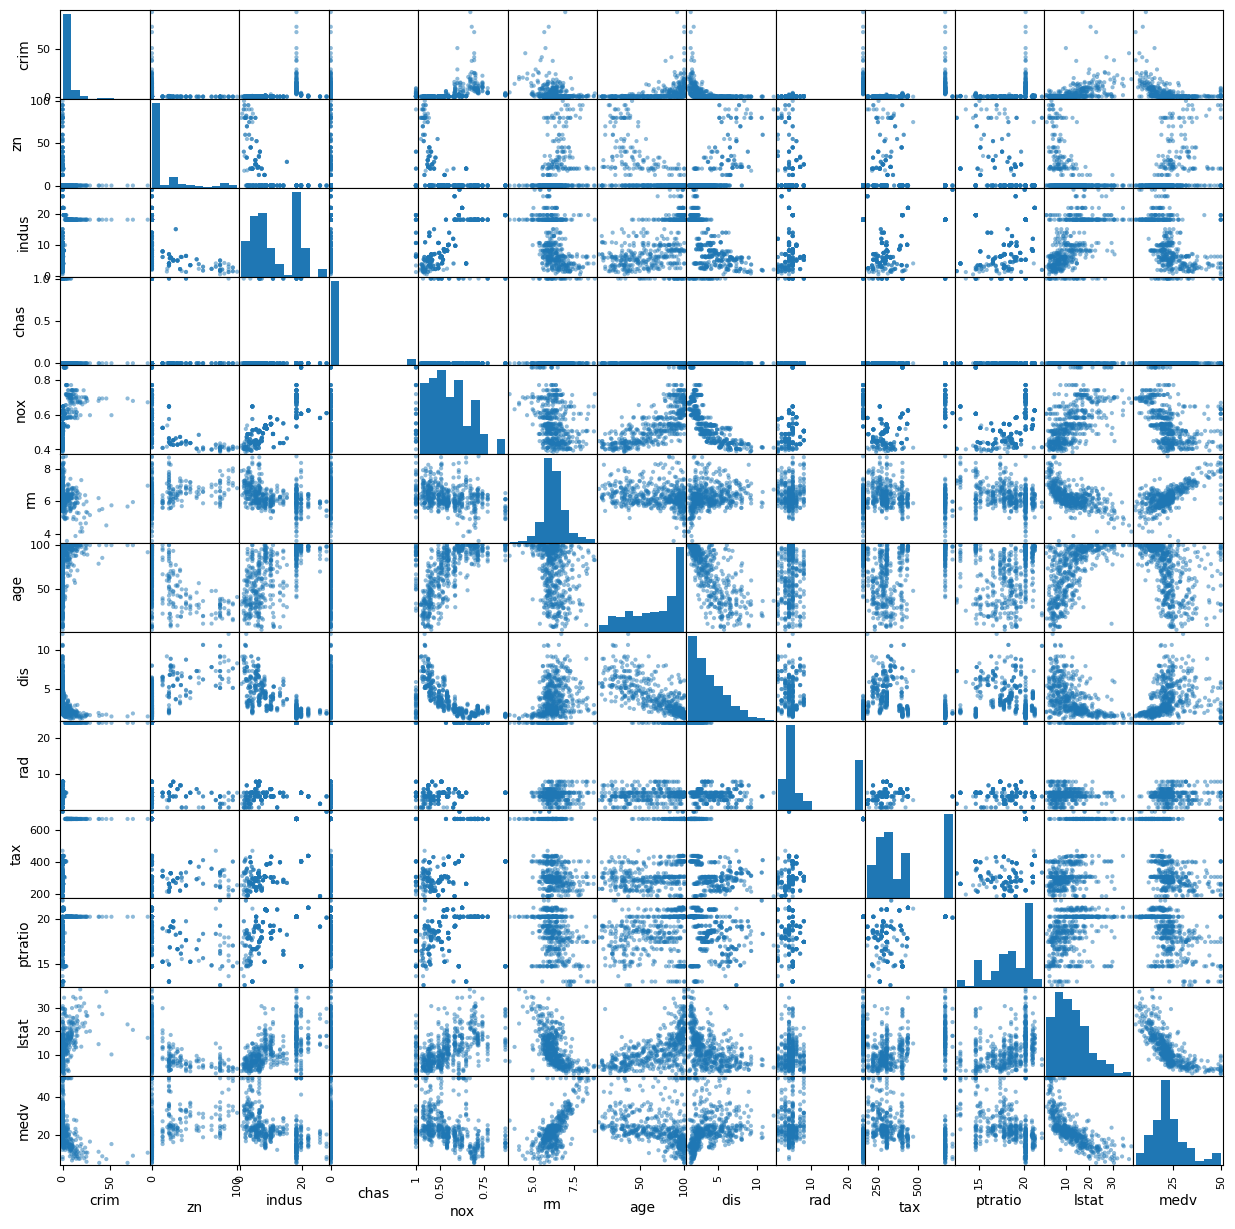

In [9]:
fig, ax = plt.subplots(figsize=(15,15))

pd.plotting.scatter_matrix(boston, ax=ax);

- some variable are not suitable for scatterplots
- A filtered scattermatrix will collect useful linear relationships.

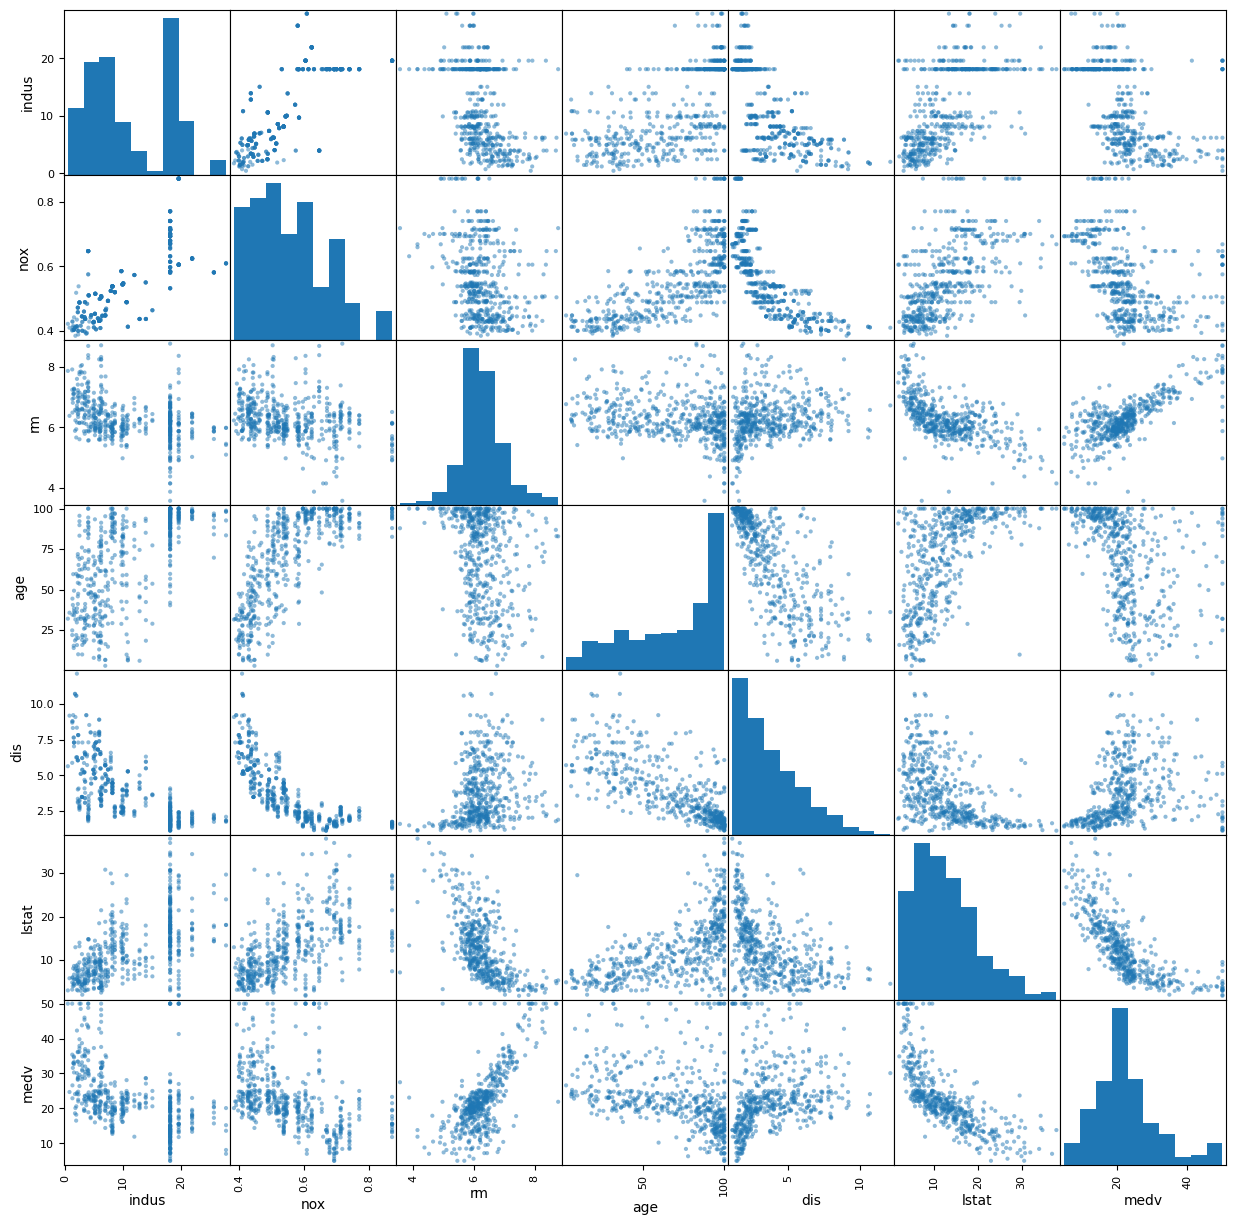

In [6]:
pd.plotting.scatter_matrix(boston[['indus', 'nox', 'rm', 'age', 'dis', 'lstat', 'medv']], figsize=(15, 15));

Some relationships are linear and others show no correlation.

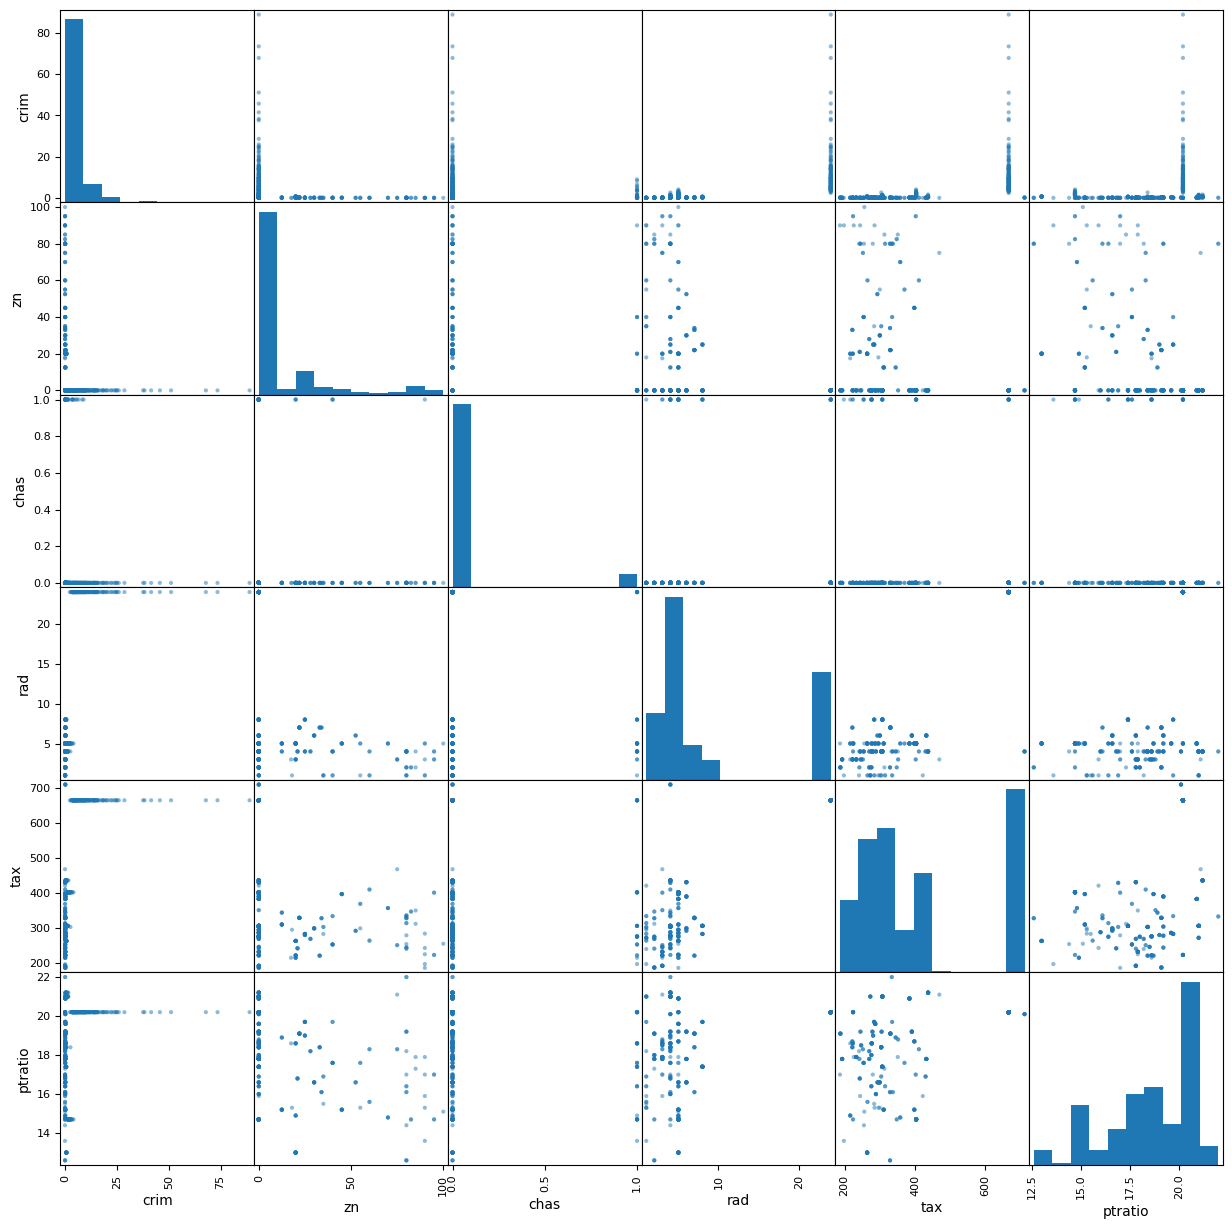

In [11]:
pd.plotting.scatter_matrix(boston.drop(['indus', 'nox', 'rm', 'age', 'dis', 'lstat', 'medv'], axis=1), figsize=(15, 15));

(d) Are any of the predictors associated with per capita crime rate?
If so, explain the relationship.


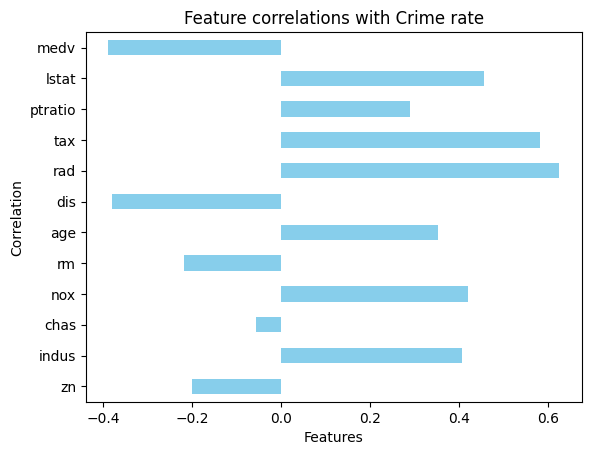

In [46]:
correlation = boston.drop('crim', axis=1).corrwith(boston['crim'])

correlation.plot(kind='barh', color='skyblue')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.title('Feature correlations with Crime rate')
plt.show();

- Accessibility to radial highways, tax and others show positive correlation with crime rates.
- Median value $ weighted mean of distance show negative correlations.

- The crime rate range from `0.006320` to `88.976200` showing the wide range of rates. Some suburbs having peak and others low crime rates.
- The tax range from `187` to `711` suggesting tax variability where some suburbs have low taxes and others have imposed high taxes.
- Pupil-Teacher ratio is from `12` to `22` showing narrower range in comparison with tax and crime but it still shows the variation across the suburbs

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


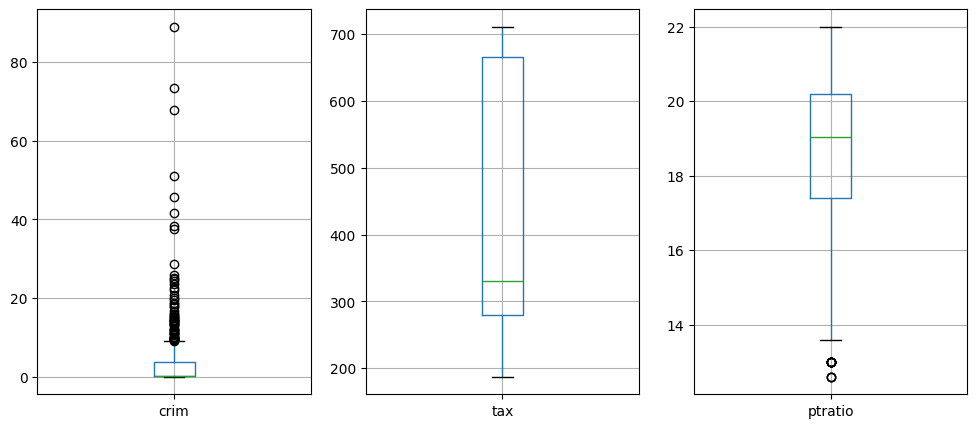

In [67]:
display(boston[["crim", "tax", "ptratio"]].describe())

fig, ax = plt.subplots(ncols=3, figsize=(12, 5))
boston.boxplot('crim', ax=ax[0])
boston.boxplot('tax', ax=ax[1])
boston.boxplot('ptratio', ax=ax[2])
plt.show();

`35` suburbs found in the charles river

In [75]:
boston[boston['chas'] == 1]['chas'].count()

35

The median pupil teacher ratio is `19.05`

In [76]:
boston['ptratio'].describe()

count    506.000000
mean      18.455534
std        2.164946
min       12.600000
25%       17.400000
50%       19.050000
75%       20.200000
max       22.000000
Name: ptratio, dtype: float64

- crim: per capita crime rate by town.

- zn: proportion of residential land zoned for lots over 25,000 sq.ft.

- indus: proportion of non-retail business acres per town.

- chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

- nox: nitrogen oxides concentration (parts per 10 million).

- rm: average number of rooms per dwelling.

- age: proportion of owner-occupied units built prior to 1940.

- dis: weighted mean of distances to five Boston employment centres.

- rad: index of accessibility to radial highways.

- tax: full-value property-tax rate per $10,000.

- ptratio: pupil-teacher ratio by town.

- lstat: lower status of the population (percent).

- medv: median value of owner-occupied homes in $1000s.


In [77]:
boston['medv'].describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: medv, dtype: float64

2 suburbs lie within the lowest median value

In [87]:
boston[boston['medv'] == 5].describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,2.00000,2.0,2.0,2.0,2.000,2.000000,2.0,2.000000,2.0,2.0,2.0,2.000000,2.0
mean,53.13630,0.0,18.1,0.0,0.693,5.568000,100.0,1.457500,24.0,666.0,20.2,26.785000,5.0
std,20.90844,0.0,0.0,0.0,0.000,0.162635,0.0,0.045396,0.0,0.0,0.0,5.381083,0.0
min,38.35180,0.0,18.1,0.0,0.693,5.453000,100.0,1.425400,24.0,666.0,20.2,22.980000,5.0
25%,45.74405,0.0,18.1,0.0,0.693,5.510500,100.0,1.441450,24.0,666.0,20.2,24.882500,5.0
50%,53.13630,0.0,18.1,0.0,0.693,5.568000,100.0,1.457500,24.0,666.0,20.2,26.785000,5.0
75%,60.52855,0.0,18.1,0.0,0.693,5.625500,100.0,1.473550,24.0,666.0,20.2,28.687500,5.0
max,67.92080,0.0,18.1,0.0,0.693,5.683000,100.0,1.489600,24.0,666.0,20.2,30.590000,5.0


In [88]:
boston.describe().loc[['min', '25%', '50%', '75%','max']]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
min,0.006320,0.0,0.46,0.0,0.385,3.5610,2.900,1.129600,1.0,187.0,12.60,1.730,5.000
25%,0.082045,0.0,5.19,0.0,0.449,5.8855,45.025,2.100175,4.0,279.0,17.40,6.950,17.025
50%,0.256510,0.0,9.69,0.0,0.538,6.2085,77.500,3.207450,5.0,330.0,19.05,11.360,21.200
75%,3.677083,12.5,18.10,0.0,0.624,6.6235,94.075,5.188425,24.0,666.0,20.20,16.955,25.000
max,88.976200,100.0,27.74,1.0,0.871,8.7800,100.000,12.126500,24.0,711.0,22.00,37.970,50.000


In [ ]:
https://www.kaggle.com/code/yutakatarokusumah/boston-dataset-islp-exercise

https://rstudio-pubs-static.s3.amazonaws.com/1267491_7310e0b864414e22a05ddc8e6c386d40.html